# Objectif
Évaluer la qualité, la structure et l’exploitabilité des données de courses (2006–2025)

# Chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("../data/processed/results.parquet")

# Vérification de la qualité du parsing

In [2]:
df.shape

(114777, 12)

In [3]:
df.head()

,Position,Nom,Club,Sexe,Categorie,Position Catégorie,Temps,NomCourse,Date,Distance,source_file,racekey
0,1,Simonet Yves,P8,H,SEN,1,0:39:48,La Neupreenne - Neupre,2017-03-12,11.0,170312-CONDRUSIEN-CHRONORACE-NEUPRE-11000.pdf,la neupreenne - neupre_2017-03-12_11.0
1,2,Honnay Xavier,,H,SEN,2,0:39:49,La Neupreenne - Neupre,2017-03-12,11.0,170312-CONDRUSIEN-CHRONORACE-NEUPRE-11000.pdf,la neupreenne - neupre_2017-03-12_11.0
2,3,Corswarem Pierre-Henri,Foulees Du Plai,H,SEN,3,0:39:53,La Neupreenne - Neupre,2017-03-12,11.0,170312-CONDRUSIEN-CHRONORACE-NEUPRE-11000.pdf,la neupreenne - neupre_2017-03-12_11.0
3,4,Grilo Carvalho Thomas,Foulees Du Plai,H,SEN,4,0:39:54,La Neupreenne - Neupre,2017-03-12,11.0,170312-CONDRUSIEN-CHRONORACE-NEUPRE-11000.pdf,la neupreenne - neupre_2017-03-12_11.0
4,5,Schmitz Bertrand,Foulees Du Plai,H,SEN,5,0:39:54,La Neupreenne - Neupre,2017-03-12,11.0,170312-CONDRUSIEN-CHRONORACE-NEUPRE-11000.pdf,la neupreenne - neupre_2017-03-12_11.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114777 entries, 0 to 114776
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Position            114777 non-null  str           
 1   Nom                 114777 non-null  str           
 2   Club                113473 non-null  str           
 3   Sexe                114777 non-null  str           
 4   Categorie           114777 non-null  str           
 5   Position Catégorie  114777 non-null  str           
 6   Temps               114777 non-null  str           
 7   NomCourse           114777 non-null  str           
 8   Date                114777 non-null  datetime64[us]
 9   Distance            114777 non-null  float64       
 10  source_file         114777 non-null  str           
 11  racekey             114777 non-null  str           
dtypes: datetime64[us](1), float64(1), str(10)
memory usage: 26.6 MB


In [5]:
df.describe(include='all')

,Position,Nom,Club,Sexe,Categorie,Position Catégorie,Temps,NomCourse,Date,Distance,source_file,racekey
count,114777,114777,113473,114777,114777,114777,114777,114777,114777,114777.000000,114777,114777
unique,571,25190,3414,5,55,209,12309,176,NaN,NaN,573,566
top,3,Robinet Frederic,,H,SEN,1,1:02:17,La Neupreenne - Neupre,NaN,NaN,170512-CONDRUSIEN-CHRONORACE-BOIS BORSU-11510-...,le jogging des 2 provinces - bois-et-borsu_201...
freq,571,246,65200,80484,14226,6233,46,5817,NaN,NaN,570,570
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-11-19 13:51:18.146318,10.240265,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2006-04-15 00:00:00,2.850000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-06-14 00:00:00,6.550000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-05-27 00:00:00,11.200000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-06-21 00:00:00,12.200000,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-05 00:00:00,28.000000,NaN,NaN


## Sexe

In [6]:
df["Sexe"].unique()

<ArrowStringArray>
['H', 'F', 'X', '', 'F NEUF MOULIN']
Length: 5, dtype: str

In [7]:
df[~df["Sexe"].isin(["H", "F", "X"])]

,Position,Nom,Club,Sexe,Categorie,Position Catégorie,Temps,NomCourse,Date,Distance,source_file,racekey
89253,254,2264 N.N.,,,,1,03:14:35,La Clavieroise,2025-06-08,6.23,20250806ClavierPC.pdf,la clavieroise_2025-06-08_6.23
96838,243,Mergeai Agnes,F Neuf Moulin,F NEUF MOULIN,A3,6,01:01:09,Le Jog&Trail De Villers-Le-Temple,2025-07-25,6.50,20250725VltPC.pdf,le jog&trail de villers-le-temple_2025-07-25_6.5


Une entrée à éliminer (nom pas valide)
Une entrée à corriger (garder club = Neuf Moulin et Sexe = F)

## Catégorie

In [29]:
sorted(df["Categorie"].unique())

['',
 '#N/A',
 '#REF!',
 '0',
 'A1',
 'A2',
 'A3',
 'A4',
 'AI1',
 'AI2',
 'AI3',
 'AI4',
 'DA',
 'DAM',
 'DISF',
 'DISH',
 'ED',
 'EF',
 'EH',
 'ESF',
 'ESH',
 'ESP',
 'F',
 'FIL',
 'GAR',
 'H',
 'JF',
 'JH',
 'JUF',
 'JUH',
 'SD',
 'SE',
 'SEF',
 'SEH',
 'SEN',
 'SH',
 'V1',
 'V1F',
 'V1H',
 'V2',
 'V2F',
 'V2H',
 'V3',
 'V3F',
 'V3H',
 'V4',
 'V4F',
 'V4H',
 'V5',
 'VE1',
 'VE2',
 'VE3',
 'VE4',
 'XXX',
 'xxx']

Harmoniser les catégories:
VE1 = V1
SEN = SEH
ESP = ESH
ESF = EF
DA = DAM

## Nom des Courses

In [31]:
sorted(df["NomCourse"].unique())

['10 Miles De Vyle Tharoul',
 "A Pid Po L'Bwes - Fraiture",
 "A Pid Po L'Bwes - Fraiture En Condroz",
 "A Pid Po L'Bwes - Fraiture I",
 "A Pid Po L'Bwes - Fraiture-En-Condroz",
 "A Pid Po L'Bwes Fraiture",
 'A Travers Nos Forets - Kin',
 'Ap Modave Run - Vierset-Barse',
 'Au Tour De Villers-Aux-Tours',
 'Autour De Villers-Aux-Tours',
 'Aux Alentours Des Huy Miles - Tihange',
 'Bois & Borsu',
 'Bois Et Borsu',
 'Bomal',
 "Corrdida D'Hermalle - Hermalle Sous Huy",
 'Corrida Des Fermes Et Chateaux - Villers-Le-Temple',
 'Corrida Nocturne - Vierset-Barse',
 "Course Nature Du Grand Bois D'Anthisnes",
 'Courses Des Chemins Communaux - Hermalle-Sous-Huy',
 'Entre Vyle & Bois-Et-Borsu',
 'Entre Vyle & Campagne - Vyle',
 'Entre Vyle Et Bois Borsu',
 'Entre Vyle Et Campagne',
 'Entre Vyle Et Campagne - Vyle Et Tharoul',
 'Entre Vyle Et Campagne - Vyle Tharoul',
 'Entre Vyle Et Campagne - Vyle-Tharoul',
 'Entre Vyle Et Campagne A Vyle Et Tharoul',
 'Entre Vyle Ete Campagne - Vyle Et Tharoul',
 'F

In [32]:
df[df["NomCourse"] == 'Sef : 29 V4F : 0 Seh : 23 V4H : 0' ]

,Position,Nom,Club,Sexe,Categorie,Position Catégorie,Temps,NomCourse,Date,Distance,source_file,racekey,year,time_seconds
41151,1,Van Der Zwalmen Sabine,Riwa,F,SEF,1,0:22:06,Sef : 29 V4F : 0 Seh : 23 V4H : 0,2012-06-08,6.0,2012-HCH-CC-VYLE-6.00.pdf,sef : 29 v4f : 0 seh : 23 v4h : 0_2012-06-08_6.0,2012,1326.0
41152,2,Baudoin Philippe,,H,V1H,1,0:23:15,Sef : 29 V4F : 0 Seh : 23 V4H : 0,2012-06-08,6.0,2012-HCH-CC-VYLE-6.00.pdf,sef : 29 v4f : 0 seh : 23 v4h : 0_2012-06-08_6.0,2012,1395.0
41153,3,Braquet Martin,,H,ESH,1,0:23:30,Sef : 29 V4F : 0 Seh : 23 V4H : 0,2012-06-08,6.0,2012-HCH-CC-VYLE-6.00.pdf,sef : 29 v4f : 0 seh : 23 v4h : 0_2012-06-08_6.0,2012,1410.0
41154,4,Fraineux Jerome,Acvise,H,SEH,1,0:23:42,Sef : 29 V4F : 0 Seh : 23 V4H : 0,2012-06-08,6.0,2012-HCH-CC-VYLE-6.00.pdf,sef : 29 v4f : 0 seh : 23 v4h : 0_2012-06-08_6.0,2012,1422.0
41155,5,Corswarem Pierre-Henri,Wac,H,SEH,2,0:24:06,Sef : 29 V4F : 0 Seh : 23 V4H : 0,2012-06-08,6.0,2012-HCH-CC-VYLE-6.00.pdf,sef : 29 v4f : 0 seh : 23 v4h : 0_2012-06-08_6.0,2012,1446.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41277,128,Letecheur Marie,,F,ESF,14,0:54:53,Sef : 29 V4F : 0 Seh : 23 V4H : 0,2012-06-08,6.0,2012-HCH-CC-VYLE-6.00.pdf,sef : 29 v4f : 0 seh : 23 v4h : 0_2012-06-08_6.0,2012,3293.0
41278,129,Letecheur Clemence,,F,ESF,15,0:54:55,Sef : 29 V4F : 0 Seh : 23 V4H : 0,2012-06-08,6.0,2012-HCH-CC-VYLE-6.00.pdf,sef : 29 v4f : 0 seh : 23 v4h : 0_2012-06-08_6.0,2012,3295.0
41279,130,Collette Alexandra,,X,xxx,,0:54:57,Sef : 29 V4F : 0 Seh : 23 V4H : 0,2012-06-08,6.0,2012-HCH-CC-VYLE-6.00.pdf,sef : 29 v4f : 0 seh : 23 v4h : 0_2012-06-08_6.0,2012,3297.0
41280,131,Simek Coralie,,F,SEF,29,1:01:06,Sef : 29 V4F : 0 Seh : 23 V4H : 0,2012-06-08,6.0,2012-HCH-CC-VYLE-6.00.pdf,sef : 29 v4f : 0 seh : 23 v4h : 0_2012-06-08_6.0,2012,3666.0


--> Deux noms de course (Havelange à corriger)

Analyse des distances

In [44]:
df[["NomCourse", "Distance", "source_file"]].drop_duplicates()

,NomCourse,Distance,source_file
0,La Neupreenne - Neupre,11.00,170312-CONDRUSIEN-CHRONORACE-NEUPRE-11000.pdf
556,La Condrusienne - Solieres,6.90,2012-CONDRUSIEN-SOLIERES-6.9.pdf
613,Le Jogging De La Piscine - Ocquier,5.50,180622-OCQUIER-5500.pdf
832,Le Jogging Du Blanc Gravier - Liege (Sart-Tilman),5.00,240505-CONDRUSIEN-GOALTIMING-JOGGING DU BLANC ...
1009,La Corrida D'Hermalle-Sous-Huy,10.38,2011 - CONDRUZIEN - HERMALLE-SOUS-HUY (10.38).pdf
...,...,...,...
114046,Jogging De La Piscine Ocquier,11.60,20250627OcquierGC.pdf
114259,La Corrida D'Hermalle-Sous-Huy,5.00,170720-CONDRUSIEN-CHRONORACE-HERMALLE-5000.pdf
114430,Les Tidges D'Havlondje - Havelange,4.60,161008-CONDRUSIEN-HAVELANGE-4600.pdf
114552,Entre Vyle & Bois-Et-Borsu,5.52,210925-CONDRUSIEN-GOAL TIMING-VYLE1BOIS-5500.pdf


Errerur de récupération de la distance pour le fichier:
- 2012-CONDRUSIEN-MODAVE-11.30.pdf 5km --> 11.3km
- 210807-CONDRUSIEN-GOAL TIMING-VILLERS AUX TOURS-5000.pdf 10km --> 5.5km
- 2015-CONDRUSIEN-FRAITURE 2- 5.29.pdf 20km --> 5.29km
- 2015-CONDRUSIEN-FRAITURE 2- 9.2.pdf 20 km --> 9.2km

## Nom des coureurs

In [30]:
sorted(df["Nom"].unique())

['#N/A',
 '(Cid:10)Simonet Yves',
 "0'Connor Michel",
 '2264 N.N.',
 '4157 De Simone',
 '4194 N.N.',
 '4226 N.N.',
 '6034 N.N.',
 '6214 N.N.',
 '83 Sarah',
 'A A',
 'Aaa Bbb',
 'Aarnoutse Pieter',
 'Abascal Bruno',
 'Abbruzzese Sabrina',
 'Abbruzzezse Sabrina',
 'Abdalah Moussa',
 'Abdelkafi Hedi',
 'Abdelman Vincent',
 'Abdelmoumne Mohamed',
 'Abdelmoumni',
 'Abdelmoumni Mohamed',
 'Abdelmounani Mohamed',
 'Abduli Ilir',
 'Abdullahi Mohamed',
 'Abdullani Mohamed',
 'Abdulramman Moubarak',
 'Aberle Manfred',
 'Abid Hedia',
 'Abinet Estelle',
 'Abo Jrai Mohammed',
 'Aboubakr Omar',
 'Aboumerrouane Rihab',
 'Abraham Christophe',
 'Abraham Jean-Francois',
 'Abraham Vinciane',
 'Abraham Zellian',
 'Abrans Maxime',
 'Abrassart Jacqueline',
 'Absil Bertrand',
 'Absil Joel',
 'Absil Patrick',
 'Accary Florence',
 'Achaert Yves',
 'Ackaert Noel',
 'Ackaert Yves',
 'Ackrert Yves',
 'Acquistapace Sarah',
 'Acusilas Jean-Yves',
 'Adam Adrien',
 'Adam Camille',
 'Adam Catherine',
 'Adam Christelle

Supprimer les noms qui commencent pas un nombre ou sont “#N/A"
Split sur ')' et ne prendre que la fin
Trouver un moyen pour corriger les noms
 'Abbruzzese Sabrina',
 'Abbruzzezse Sabrina',
 'Abdalah Moussa',
 'Abdelkafi Hedi',
 'Abdelman Vincent',
 'Abdelmoumne Mohamed',
 'Abdelmoumni',
 'Abdelmoumni Mohamed',
 'Abdelmounani Mohamed',


In [13]:
df["year"] = df["Date"].dt.year

In [14]:
df.groupby("year").size()

year
2006      688
2007      650
2008     3327
2009     3007
2010     3458
2011     5353
2012     8189
2013     8280
2014     8811
2015     9768
2016    11005
2017    11466
2018     7229
2019     7519
2021     3064
2022     3360
2023     5724
2024     5599
2025     8280
dtype: int64

In [15]:

df.groupby("year")["Nom"].nunique()

year
2006     449
2007     457
2008    1337
2009    1196
2010    1521
2011    2357
2012    3059
2013    3511
2014    3710
2015    4000
2016    4445
2017    4444
2018    3132
2019    3268
2021    1531
2022    1764
2023    2697
2024    2775
2025    3940
Name: Nom, dtype: int64

In [16]:
df.groupby("year")["NomCourse"].nunique()

year
2006     4
2007     3
2008    18
2009    17
2010    17
2011    17
2012    22
2013    21
2014    25
2015    22
2016    27
2017    21
2018    20
2019    21
2021    13
2022    13
2023    18
2024    15
2025    19
Name: NomCourse, dtype: int64

# Analyse des coureurs

In [17]:
runner_counts = df["Nom"].value_counts()
runner_counts.describe()

count    25190.000000
mean         4.556451
std         12.689294
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        246.000000
Name: count, dtype: float64

25190 nom de coureurs différents

In [18]:
runner_counts.value_counts().sort_index()

count
1      14881
2       3491
3       1666
4        961
5        626
       ...  
211        1
225        1
231        1
238        1
246        2
Name: count, Length: 161, dtype: int64

14897 coureurs qui n'ont participé qu'une fois. Attention, parmis eux, certainement un grand nombre où il s'agit d'erreurs d'encodage

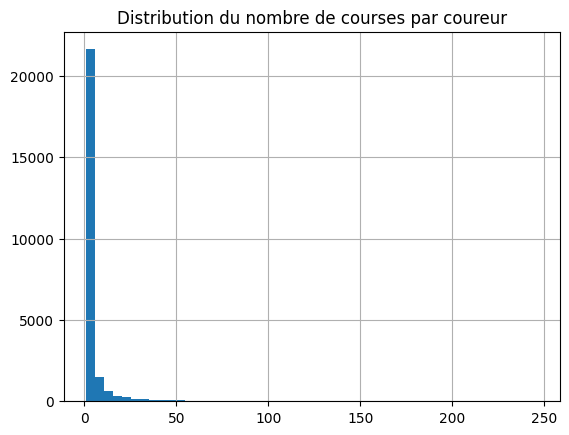

In [20]:
runner_counts.hist(bins=50)
plt.title("Distribution du nombre de courses par coureur")
plt.show()

In [28]:
# Coureurs avec au moins 3 courses
active = runner_counts[runner_counts >= 3].index

df[df["Nom"].isin(active)].groupby("Nom")["Distance"].agg(["mean", "min", "max"])

,mean,min,max
Nom,,,
A A,11.88250,10.50,13.800
Abascal Bruno,9.40000,5.50,12.100
Abdelkafi Hedi,11.53500,11.27,12.000
Abdelman Vincent,11.34500,10.38,12.500
Abdelmoumni Mohamed,11.12500,10.20,13.500
...,...,...,...
Zielinski Michel,12.64375,12.00,13.175
Zigrossi Mauro,13.72000,11.80,17.600
Zimmer Dylan,10.31500,5.50,12.660


6818 coureurs avec au moins 3 courses.

In [45]:
df[df['Nom'].isin(["Abdullahi Mohamed","Abdullani Mohamed"])]

,Position,Nom,Club,Sexe,Categorie,Position Catégorie,Temps,NomCourse,Date,Distance,source_file,racekey,year,time_seconds
31543,9,Abdullani Mohamed,,H,SEH,7,0:44:55,Villers-Le-Temple,2011-07-29,12.00,2011 - CONDRUZIEN - VILLERS-LE-TEMPLE (11.47).pdf,villers-le-temple_2011-07-29_12.0,2011,2695.0
35486,3,Abdullahi Mohamed,,H,SE,3,0:34:53,Pailhe,2010-09-17,10.00,2010 - ARCHIVE - PAILHE (10.0).pdf,pailhe_2010-09-17_10.0,2010,2093.0
49587,8,Abdullani Mohamed,,H,SEH,7,0:40:43,Terwagne,2012-04-20,10.90,2012-CONDRUSIEN-TERWAGNE-10.90.pdf,terwagne_2012-04-20_10.9,2012,2443.0
55317,3,Abdullahi Mohamed,,H,SEH,2,0:54:28,Bois & Borsu,2012-05-05,14.70,2012-CONDRUSIEN-BOIS&BORSU-14.70.pdf,bois & borsu_2012-05-05_14.7,2012,3268.0
58889,3,Abdullahi Mohamed,,H,SE,2,1:18:41,Fraiture En Condroz,2010-09-25,19.55,2010 - ARCHIVE - FRAITURE II (19.5).pdf,fraiture en condroz_2010-09-25_19.55,2010,4721.0
60291,29,Abdullani Mohamed,,H,SEH,16,0:49:37,Les Avins,2012-02-25,12.00,2012-CONDRUSIEN-LES AVINS-12.00.pdf,les avins_2012-02-25_12.0,2012,2977.0
86945,24,Abdullahi Mohamed,,H,SE,13,0:53:04,Jogging Des Poudingues - Ombret,2010-10-16,12.47,2010 - ARCHIVE - OMBRET (12.47).pdf,jogging des poudingues - ombret_2010-10-16_12.47,2010,3184.0
87235,159,Abdullani Mohamed,,H,SEH,50,0:59:15,Fraiture En Condroz,2011-05-13,11.80,2011 - CONDRUZIEN - FRAITURE (11.80).pdf,fraiture en condroz_2011-05-13_11.8,2011,3555.0
93222,8,Abdullahi Mohamed,,H,SEH,8,0:46:25,La Neupreenne,2012-03-18,12.00,2012-CONDRUSIEN-NEUPRE-11.98.pdf,la neupreenne_2012-03-18_12.0,2012,2785.0
104162,33,Abdullani Mohamed,,H,SEH,14,0:53:37,A Pid Po L'Bwes - Fraiture En Condroz,2013-05-10,12.30,2013-CONDRUSIEN-FRAITURE1-12.30.pdf,a pid po l'bwes - fraiture en condroz_2013-05-...,2013,3217.0
